## Load Dependencies

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Download stopwords if not already downloaded
# nltk.download('stopwords')

## Load Data

In [2]:
df=pd.read_csv("../data/spam.csv",encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df=df[["v1","v2"]]
df.rename(columns={"v1":"label","v2":"message"},inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


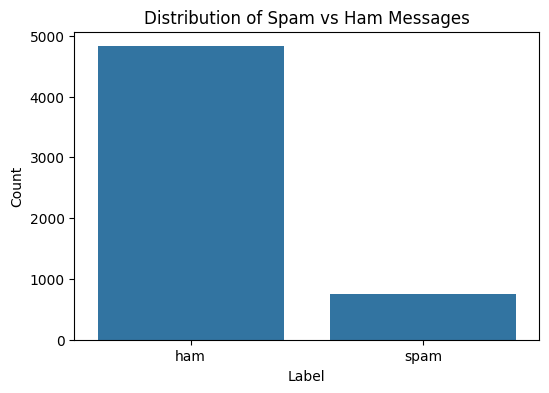

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Spam vs Ham Messages')
plt.xlabel('Label')
plt.ylabel('Count')

plt.show()

## Preprocessing

In [5]:
stopwords_set=set(stopwords.words("english"))

def clean_text(text):
    text=text.lower()
    text=re.sub(r"[^0-9a-zA-Z]"," ",text)
    text=re.sub(r"\s+"," ",text)
    text=" ".join(word for word in text.split() if word not in stopwords_set)
    return text

In [6]:
df["cleaned_text"]=df["message"].apply(clean_text)
df["label"]=df["label"].map({"ham":0,"spam":1})
df.head()

,label,message,cleaned_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


## Splitting the Input

In [7]:
X=df["cleaned_text"]
y=df["label"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
tfidf=TfidfVectorizer(max_features=5000,stop_words="english",ngram_range=(1,2))
X_train_vec=tfidf.fit_transform(X_train)
X_test_vec=tfidf.transform(X_test)

## MODELS

### 1/Decision Tree

In [9]:
dt=DecisionTreeClassifier(max_depth=10,min_samples_split=5,random_state=42)
dt.fit(X_train_vec,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

Final Test Accuracy: 94.8879%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       965
        Spam       0.96      0.65      0.77       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115


Confusion Matrix:


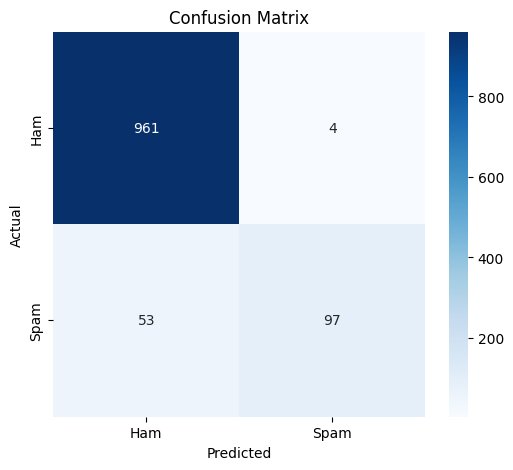

In [10]:
dt_y_pred=dt.predict(X_test_vec)

print(f"Final Test Accuracy: {accuracy_score(y_test,dt_y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test,dt_y_pred,target_names=['Ham','Spam']))
print("\nConfusion Matrix:")
conf_matrix=confusion_matrix(y_test,dt_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [11]:
def predict_message(message, model, vectorizer):
    message_tfidf=vectorizer.transform([message])
    probabilities=model.predict_proba(message_tfidf)[0]
    prediction=model.predict(message_tfidf)[0]
    label="SPAM" if prediction==1 else "HAM"
    ham_percentage=probabilities[0]*100
    spam_percentage=probabilities[1]*100
    return label,spam_percentage,ham_percentage

# Test messages
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: http://fake-link.com",
    "Thanks for the movie recommendation, I really enjoyed it!",
    "FREE entry for a Disney holiday! Text WIN to 80085 now!",
    "Can you pick up some milk on your way home?"
]

print("Testing custom messages:")
print("-" * 60)
for msg in test_messages:
    label, spam_pct,ham_pct = predict_message(msg,dt,tfidf)
    print(f"Message: {msg}...")
    print(f"Prediction: {label} (Confidence: {spam_pct:.1f}% Spam | {ham_pct:.1f}% Ham)\n")

Testing custom messages:
------------------------------------------------------------
Message: Congratulations! You've won a free iPhone. Click here to claim now!...
Prediction: SPAM (Confidence: 100.0% Spam | 0.0% Ham)

Message: Hey, are we still meeting for lunch tomorrow?...
Prediction: HAM (Confidence: 3.8% Spam | 96.2% Ham)

Message: URGENT: Your account has been compromised. Verify now: http://fake-link.com...
Prediction: HAM (Confidence: 0.0% Spam | 100.0% Ham)

Message: Thanks for the movie recommendation, I really enjoyed it!...
Prediction: HAM (Confidence: 3.8% Spam | 96.2% Ham)

Message: FREE entry for a Disney holiday! Text WIN to 80085 now!...
Prediction: SPAM (Confidence: 100.0% Spam | 0.0% Ham)

Message: Can you pick up some milk on your way home?...
Prediction: HAM (Confidence: 3.8% Spam | 96.2% Ham)



### 2/KNN

In [12]:
knn_tfidf=TfidfVectorizer(max_features=2000,stop_words='english')
X_train_knn=knn_tfidf.fit_transform(X_train)
X_test_knn=knn_tfidf.transform(X_test)

In [15]:
knn=KNeighborsClassifier(n_neighbors=5,metric="cosine")
knn.fit(X_train_knn,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Final Test Accuracy: 97.1300%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       965
        Spam       0.98      0.80      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:


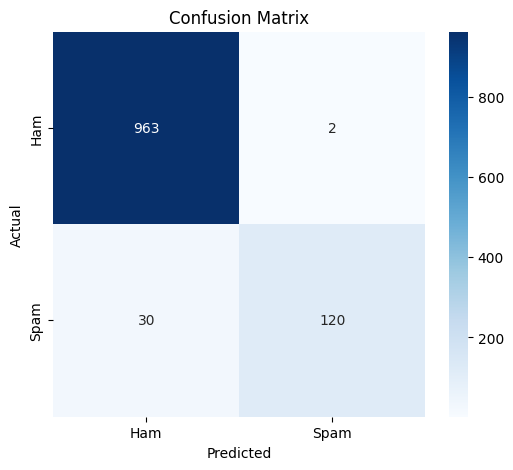

In [16]:
knn_y_pred=knn.predict(X_test_knn)

print(f"Final Test Accuracy: {accuracy_score(y_test,knn_y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test,knn_y_pred,target_names=['Ham','Spam']))
print("\nConfusion Matrix:")
conf_matrix=confusion_matrix(y_test,knn_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
def predict_message(message, model, vectorizer):
    message_tfidf=vectorizer.transform([message])
    probabilities=model.predict_proba(message_tfidf)[0]
    prediction=model.predict(message_tfidf)[0]
    label="SPAM" if prediction==1 else "HAM"
    ham_percentage=probabilities[0]*100
    spam_percentage=probabilities[1]*100
    return label,spam_percentage,ham_percentage

# Test messages
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: http://fake-link.com",
    "Thanks for the movie recommendation, I really enjoyed it!",
    "FREE entry for a Disney holiday! Text WIN to 80085 now!",
    "Can you pick up some milk on your way home?"
]

print("Testing custom messages:")
print("-" * 60)
for msg in test_messages:
    label, spam_pct,ham_pct = predict_message(msg,knn,knn_tfidf)
    print(f"Message: {msg}...")
    print(f"Prediction: {label} (Confidence: {spam_pct:.1f}% Spam | {ham_pct:.1f}% Ham)\n")

Testing custom messages:
------------------------------------------------------------
Message: Congratulations! You've won a free iPhone. Click here to claim now!...
Prediction: HAM (Confidence: 40.0% Spam | 60.0% Ham)

Message: Hey, are we still meeting for lunch tomorrow?...
Prediction: HAM (Confidence: 0.0% Spam | 100.0% Ham)

Message: URGENT: Your account has been compromised. Verify now: http://fake-link.com...
Prediction: SPAM (Confidence: 80.0% Spam | 20.0% Ham)

Message: Thanks for the movie recommendation, I really enjoyed it!...
Prediction: HAM (Confidence: 0.0% Spam | 100.0% Ham)

Message: FREE entry for a Disney holiday! Text WIN to 80085 now!...
Prediction: SPAM (Confidence: 100.0% Spam | 0.0% Ham)

Message: Can you pick up some milk on your way home?...
Prediction: HAM (Confidence: 0.0% Spam | 100.0% Ham)



### 3/SVM

In [18]:
svm=SVC(kernel="linear",C=1.0,random_state=42)
svm.fit(X_train_vec,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Final Test Accuracy: 97.9372%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:


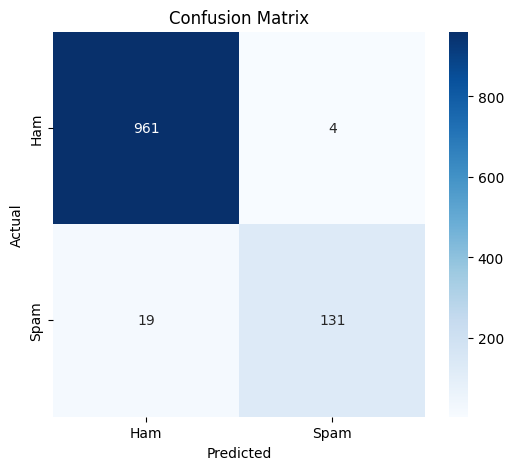

In [19]:
svm_y_pred=svm.predict(X_test_vec)

print(f"Final Test Accuracy: {accuracy_score(y_test,svm_y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test,svm_y_pred,target_names=['Ham','Spam']))
print("\nConfusion Matrix:")
conf_matrix=confusion_matrix(y_test,svm_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
def predict_message(message,model,vectorizer):
    message_tfidf=vectorizer.transform([message])
    decision_score=model.decision_function(message_tfidf)[0]
    confidence=1/(1+np.exp(-abs(decision_score)))
    prediction=model.predict(message_tfidf)[0]
    label="SPAM" if prediction==1 else "HAM"
    if prediction==1:
        spam_percentage=confidence*100
        ham_percentage=(1-confidence)*100
    else:
        ham_percentage=confidence*100
        spam_percentage=(1-confidence)*100
    return label,spam_percentage,ham_percentage

# Test messages
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: http://fake-link.com",
    "Thanks for the movie recommendation, I really enjoyed it!",
    "FREE entry for a Disney holiday! Text WIN to 80085 now!",
    "Can you pick up some milk on your way home?"
]

print("Testing custom messages:")
print("-" * 60)
for msg in test_messages:
    label, spam_pct,ham_pct = predict_message(msg,svm,tfidf)
    print(f"Message: {msg}...")
    print(f"Prediction: {label} (Confidence: {spam_pct:.1f}% Spam | {ham_pct:.1f}% Ham)\n")

Testing custom messages:
------------------------------------------------------------
Message: Congratulations! You've won a free iPhone. Click here to claim now!...
Prediction: SPAM (Confidence: 71.2% Spam | 28.8% Ham)

Message: Hey, are we still meeting for lunch tomorrow?...
Prediction: HAM (Confidence: 13.3% Spam | 86.7% Ham)

Message: URGENT: Your account has been compromised. Verify now: http://fake-link.com...
Prediction: SPAM (Confidence: 77.9% Spam | 22.1% Ham)

Message: Thanks for the movie recommendation, I really enjoyed it!...
Prediction: HAM (Confidence: 24.8% Spam | 75.2% Ham)

Message: FREE entry for a Disney holiday! Text WIN to 80085 now!...
Prediction: SPAM (Confidence: 69.6% Spam | 30.4% Ham)

Message: Can you pick up some milk on your way home?...
Prediction: HAM (Confidence: 18.9% Spam | 81.1% Ham)

